<a href="https://www.kaggle.com/code/rahadul231/dry-bean-classification-using-svm-and-knn?scriptVersionId=352791018" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Dry Bean Classification Using SVM and KNN

## Introduction

The Dry Bean Dataset contains measurements extracted from images of seven different registered varieties of dry beans. The objective of this project is to classify dry beans into their respective classes using machine learning algorithms.

In this project, two supervised machine learning algorithms are applied:

1. **Support Vector Machine (SVM)**
2. **K-Nearest Neighbors (KNN)**

The performance of the two models is evaluated and compared using accuracy, precision, recall, F1-score, confusion matrices, and classification reports.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

## 1. Load the Dataset

The dataset is loaded from the Kaggle input directory. First, the files available in the dataset directory are displayed to identify the CSV file.

In [2]:
dataset_path = "/kaggle/input/datasets/rahadul231/dry-bean-dataset"

for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rahadul231/dry-bean-dataset/Dry_Beans_Dataset.csv


In [3]:
file_path = "/kaggle/input/datasets/rahadul231/dry-bean-dataset/Dry_Beans_Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 2. Dataset Overview

Before building the classification models, the structure of the dataset is examined. This includes the number of rows and columns, feature names, data types, missing values, duplicate records, descriptive statistics, and distribution of the target classes.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of rows: 13611
Number of columns: 17

Column Names:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundne

In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Total missing values: 0
Duplicate rows: 68


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860154
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


In [7]:
print("Bean Classes:")
print(df['Class'].unique())

print("\nNumber of Classes:", df['Class'].nunique())

print("\nClass Distribution:")
print(df['Class'].value_counts())

Bean Classes:
['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']

Number of Classes: 7

Class Distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


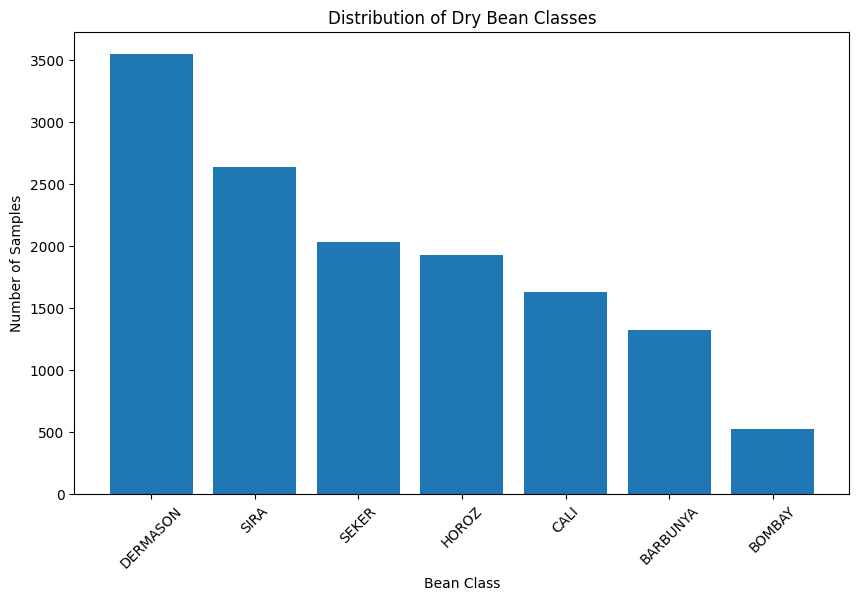

In [8]:
class_counts = df['Class'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(class_counts.index, class_counts.values)

plt.title("Distribution of Dry Bean Classes")
plt.xlabel("Bean Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

## 3. Data Preprocessing

The `Class` column is the target variable, while the remaining columns are input features.

The dataset is divided into training and testing sets using an 80:20 ratio. Stratified sampling is used to preserve the class distribution in both sets.

Feature scaling is particularly important for SVM and KNN because both algorithms are sensitive to differences in feature magnitude. Therefore, `StandardScaler` is fitted only on the training data and then applied to both the training and testing sets.

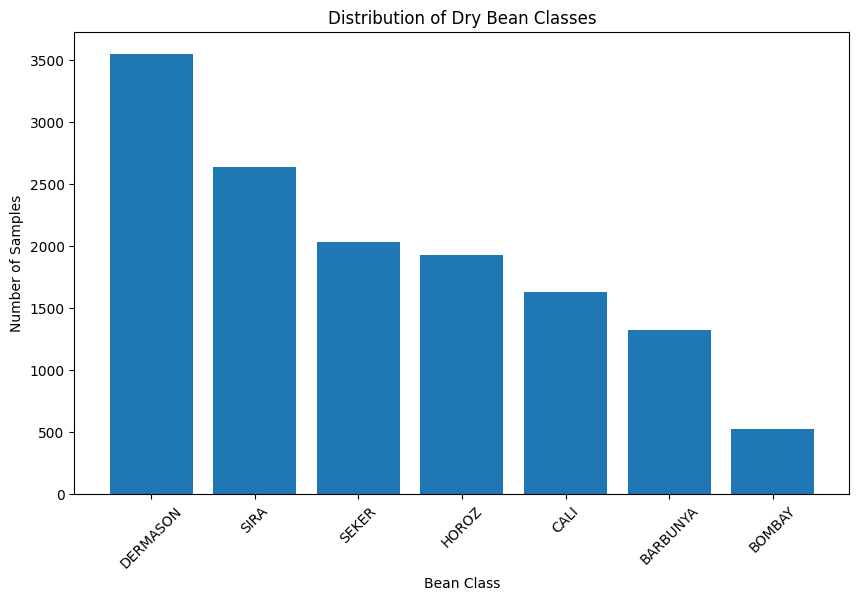

In [9]:
class_counts = df['Class'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(class_counts.index, class_counts.values)

plt.title("Distribution of Dry Bean Classes")
plt.xlabel("Bean Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (13611, 16)
Target vector shape: (13611,)

Features:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 10888
Testing samples: 2723


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## 4. Support Vector Machine (SVM)

Support Vector Machine is a supervised learning algorithm that attempts to find a decision boundary that separates different classes. An RBF kernel is used because it can model nonlinear relationships between the input features and bean classes.

In [13]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM model training completed.")

SVM model training completed.


In [14]:
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='weighted')
svm_recall = recall_score(y_test, svm_pred, average='weighted')
svm_f1 = f1_score(y_test, svm_pred, average='weighted')

print("SVM Performance")
print("-------------------------")
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")

SVM Performance
-------------------------
Accuracy : 0.9221
Precision: 0.9224
Recall   : 0.9221
F1 Score : 0.9222


In [15]:
print("SVM Classification Report:\n")
print(classification_report(y_test, svm_pred))

SVM Classification Report:

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.94       406
        SIRA       0.86      0.87      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



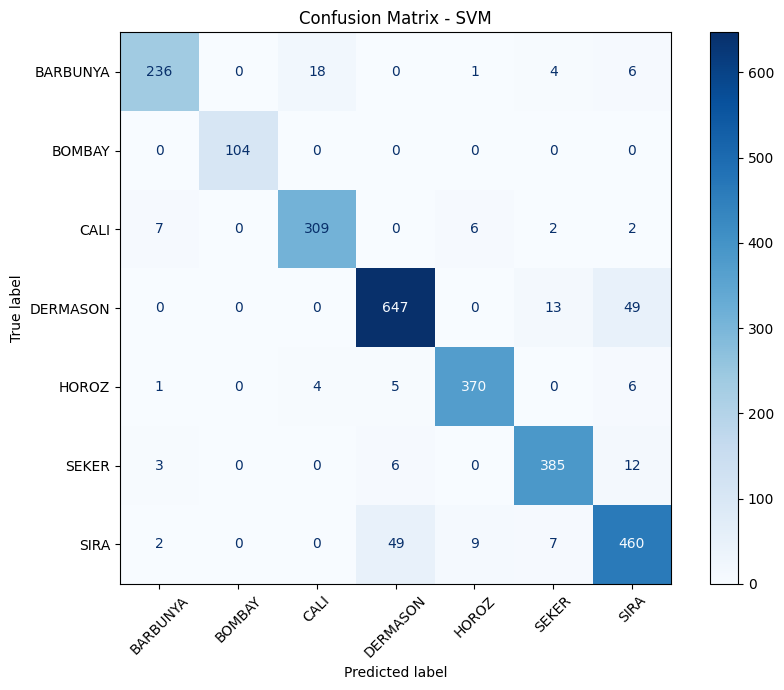

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

plt.title("Confusion Matrix - SVM")
plt.tight_layout()
plt.show()

## 5. K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a supervised learning algorithm that classifies a sample according to the classes of its nearest neighboring observations.

Because KNN relies directly on distances between samples, feature scaling is important. The value of `k` is first investigated by testing several possible numbers of neighbors.

In [17]:
k_values = range(1, 21)
knn_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    knn_accuracies.append(accuracy_score(y_test, predictions))

for k, accuracy in zip(k_values, knn_accuracies):
    print(f"k = {k:2d} | Accuracy = {accuracy:.4f}")

k =  1 | Accuracy = 0.8986
k =  2 | Accuracy = 0.9016
k =  3 | Accuracy = 0.9152
k =  4 | Accuracy = 0.9177
k =  5 | Accuracy = 0.9166
k =  6 | Accuracy = 0.9188
k =  7 | Accuracy = 0.9137
k =  8 | Accuracy = 0.9137
k =  9 | Accuracy = 0.9163
k = 10 | Accuracy = 0.9177
k = 11 | Accuracy = 0.9185
k = 12 | Accuracy = 0.9181
k = 13 | Accuracy = 0.9188
k = 14 | Accuracy = 0.9199
k = 15 | Accuracy = 0.9188
k = 16 | Accuracy = 0.9185
k = 17 | Accuracy = 0.9181
k = 18 | Accuracy = 0.9170
k = 19 | Accuracy = 0.9170
k = 20 | Accuracy = 0.9188


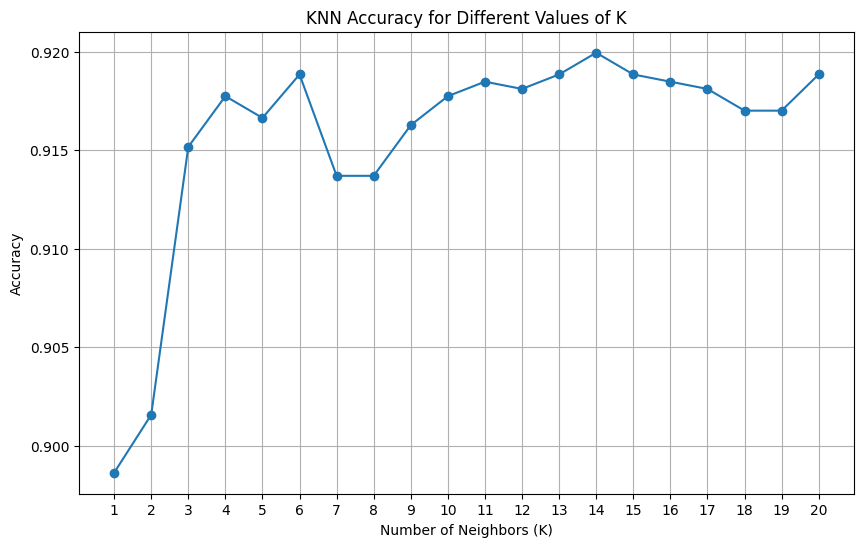

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(k_values, knn_accuracies, marker='o')

plt.title("KNN Accuracy for Different Values of K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [19]:
best_k = list(k_values)[np.argmax(knn_accuracies)]

print("Best value of K:", best_k)
print("Best validation accuracy:", round(max(knn_accuracies), 4))

Best value of K: 14
Best validation accuracy: 0.9199


In [20]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN model training completed.")

KNN model training completed.


In [21]:
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, average='weighted')
knn_recall = recall_score(y_test, knn_pred, average='weighted')
knn_f1 = f1_score(y_test, knn_pred, average='weighted')

print("KNN Performance")
print("-------------------------")
print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1 Score : {knn_f1:.4f}")

KNN Performance
-------------------------
Accuracy : 0.9199
Precision: 0.9205
Recall   : 0.9199
F1 Score : 0.9201


In [22]:
print("KNN Classification Report:\n")
print(classification_report(y_test, knn_pred))

KNN Classification Report:

              precision    recall  f1-score   support

    BARBUNYA       0.96      0.89      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.94      0.95      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



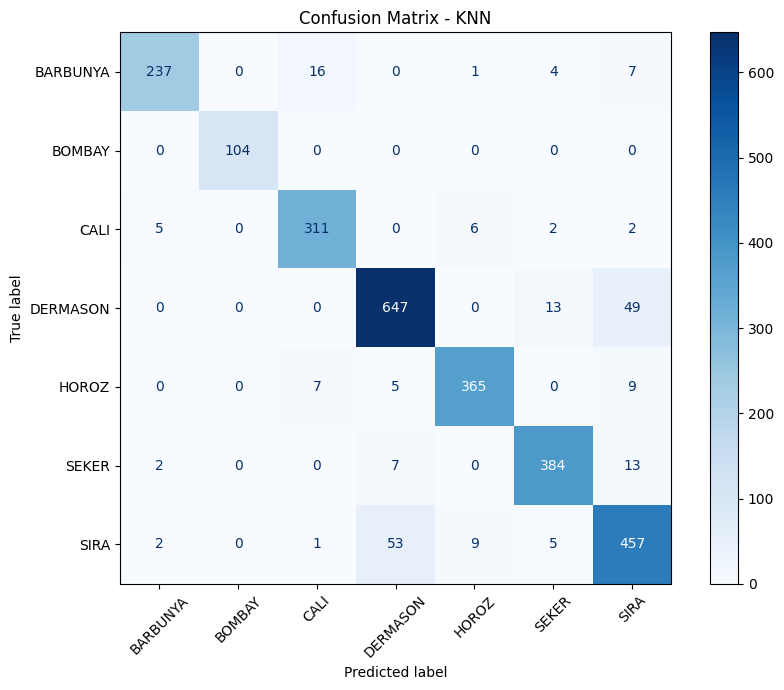

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

plt.title("Confusion Matrix - KNN")
plt.tight_layout()
plt.show()

## 6. Comparison of SVM and KNN

The two classification algorithms are compared using accuracy, weighted precision, weighted recall, and weighted F1-score. These metrics provide an overall assessment of classification performance across the seven bean classes.

In [24]:
results = pd.DataFrame({
    'Model': ['SVM', 'KNN'],
    'Accuracy': [svm_accuracy, knn_accuracy],
    'Precision': [svm_precision, knn_precision],
    'Recall': [svm_recall, knn_recall],
    'F1 Score': [svm_f1, knn_f1]
})

results.set_index('Model').round(4)

,Accuracy,Precision,Recall,F1 Score
Model,,,,
SVM,0.9221,0.9224,0.9221,0.9222
KNN,0.9199,0.9205,0.9199,0.9201


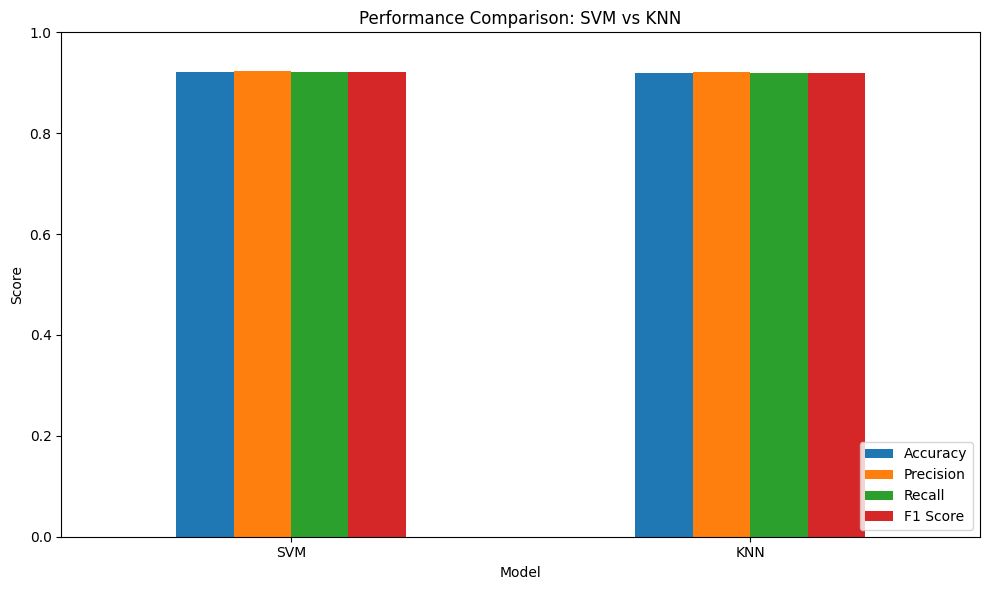

In [25]:
results_plot = results.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Performance Comparison: SVM vs KNN")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Conclusion

In this project, Support Vector Machine (SVM) and K-Nearest Neighbors (KNN) were applied to the Dry Bean Dataset for multiclass classification.

The dataset was first explored and checked for missing values and duplicate records. The input features were separated from the target class, and the data was divided into training and testing sets. Standardization was then applied because both SVM and KNN are sensitive to feature scales.

The models were evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices. For KNN, different values of K were investigated to examine how the number of neighbors affected classification performance.

The final results demonstrate the ability of both algorithms to classify the seven dry bean varieties. Their performance can be compared using the evaluation table and confusion matrices above.